In [31]:
import json
import pandas as pd

In [55]:
with open("data/data.json", "r", encoding="utf-8") as file:
    raw_data = json.load(file)

clean_data = [item for item in raw_data if item]

print(f"Original: {len(raw_data)}")
print(f"Cleaned : {len(clean_data)}")
print(f"Removed : {len(raw_data)-len(clean_data)}")

data = clean_data

Original: 6
Cleaned : 3
Removed : 3


In [56]:
first = data[0]

chart = first["parsedResponseBody"]["data"]["chartData"]

print(chart.keys())

dict_keys(['symbol', 'timeRange', 'allSymbols', 'priceBars', '__typename'])


In [57]:
metadata = []

for item in data:

    chart = item["parsedResponseBody"]["data"]["chartData"]

    metadata.append({
        "symbol": chart["symbol"],
        "timeRange": chart["timeRange"],
        "n_pricebars": len(chart["priceBars"])
    })

meta_df = pd.DataFrame(metadata)

meta_df.head()

,symbol,timeRange,n_pricebars
0,US10Y,YTD,253
1,US10Y,5Y,523
2,US10Y,ALL,183


In [58]:
symbols = []

for item in data:

    chart = item["parsedResponseBody"]["data"]["chartData"]

    for symbol in chart["allSymbols"]:

        symbols.append({
            "requested_TimeRange": chart["timeRange"],
            **symbol
        })

symbols_df = pd.DataFrame(symbols)

symbols_df.head()

,requested_TimeRange,symbol,name,shortName,last,__typename
0,YTD,US10Y,U.S. 10 Year Treasury,US 10-YR,4.502%,QuoteFields
1,5Y,US10Y,U.S. 10 Year Treasury,US 10-YR,4.504%,QuoteFields
2,ALL,US10Y,U.S. 10 Year Treasury,US 10-YR,4.502%,QuoteFields


In [59]:
pricebars = []

for item in data:

    chart = item["parsedResponseBody"]["data"]["chartData"]

    symbol = chart["symbol"]
    timerange = chart["timeRange"]

    for bar in chart["priceBars"]:

        pricebars.append({
            "symbol": symbol,
            "timeRange": timerange,
            "open": bar["open"],
            "high": bar["high"],
            "low": bar["low"],
            "close": bar["close"],
            "volume": bar["volume"],
            "tradeTime": bar["tradeTime"],
            "tradeTimeinMills": bar["tradeTimeinMills"]
        })

pricebars_df = pd.DataFrame(pricebars)
pricebars_df.head()

,symbol,timeRange,open,high,low,close,volume,tradeTime,tradeTimeinMills
0,US10Y,YTD,4.4200,4.4700,4.4100,4.4600,0,20250602000000,1748836800000
1,US10Y,YTD,4.4500,4.4700,4.4100,4.4600,0,20250603000000,1748923200000
2,US10Y,YTD,4.4500,4.4700,4.3500,4.3700,0,20250604000000,1749009600000
3,US10Y,YTD,4.3600,4.4000,4.3200,4.4000,0,20250605000000,1749096000000
4,US10Y,YTD,4.3900,4.5100,4.3800,4.5100,0,20250606000000,1749182400000


In [60]:
numeric_cols = [
    "open",
    "high",
    "low",
    "close",
    "volume"
]

for col in numeric_cols:
    pricebars_df[col] = pd.to_numeric(
        pricebars_df[col],
        errors="coerce"
    )

In [61]:
pricebars_df["tradeTime"] = pd.to_datetime(
    pricebars_df["tradeTime"],
    format="%Y%m%d%H%M%S"
)

In [62]:
pricebars_df["tradeTimeinMills"] = pd.to_numeric(
    pricebars_df["tradeTimeinMills"],
    errors="coerce"
)

pricebars_df["tradeTimeinMills"] = pd.to_datetime(
    pricebars_df["tradeTimeinMills"],
    unit="ms"
)

In [63]:
pricebars_df = (
    pricebars_df
    .sort_values(["symbol", "tradeTime"])
    .reset_index(drop=True)
)

In [64]:
pricebars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 959 entries, 0 to 958
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   symbol            959 non-null    object        
 1   timeRange         959 non-null    object        
 2   open              956 non-null    float64       
 3   high              956 non-null    float64       
 4   low               956 non-null    float64       
 5   close             956 non-null    float64       
 6   volume            956 non-null    float64       
 7   tradeTime         959 non-null    datetime64[ns]
 8   tradeTimeinMills  956 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(5), object(2)
memory usage: 67.6+ KB


In [65]:
pricebars_df.head()

,symbol,timeRange,open,high,low,close,volume,tradeTime,tradeTimeinMills
0,US10Y,ALL,10.31,13.64,10.31,12.60,0.0,1980-01-01,1980-01-01 05:00:00
1,US10Y,ALL,12.65,12.65,9.11,9.43,0.0,1980-04-01,1980-04-01 05:00:00
2,US10Y,ALL,9.49,12.04,9.44,11.84,0.0,1980-07-01,1980-07-01 04:00:00
3,US10Y,ALL,11.76,13.55,11.27,12.41,0.0,1980-10-01,1980-10-01 04:00:00
4,US10Y,ALL,12.41,13.62,12.10,13.10,0.0,1981-01-01,1981-01-01 05:00:00


In [66]:
symbol_dfs = {}

for symbol, df in pricebars_df.groupby("timeRange"):
    symbol_dfs[symbol] = df.reset_index(drop=True)

In [67]:
symbol_dfs.keys()

dict_keys(['5Y', 'ALL', 'YTD'])

In [70]:
us10y = symbol_dfs["YTD"]

us10y.head()

,symbol,timeRange,open,high,low,close,volume,tradeTime,tradeTimeinMills
0,US10Y,YTD,4.42,4.47,4.41,4.46,0.0,2025-06-02,2025-06-02 04:00:00
1,US10Y,YTD,4.45,4.47,4.41,4.46,0.0,2025-06-03,2025-06-03 04:00:00
2,US10Y,YTD,4.45,4.47,4.35,4.37,0.0,2025-06-04,2025-06-04 04:00:00
3,US10Y,YTD,4.36,4.40,4.32,4.40,0.0,2025-06-05,2025-06-05 04:00:00
4,US10Y,YTD,4.39,4.51,4.38,4.51,0.0,2025-06-06,2025-06-06 04:00:00


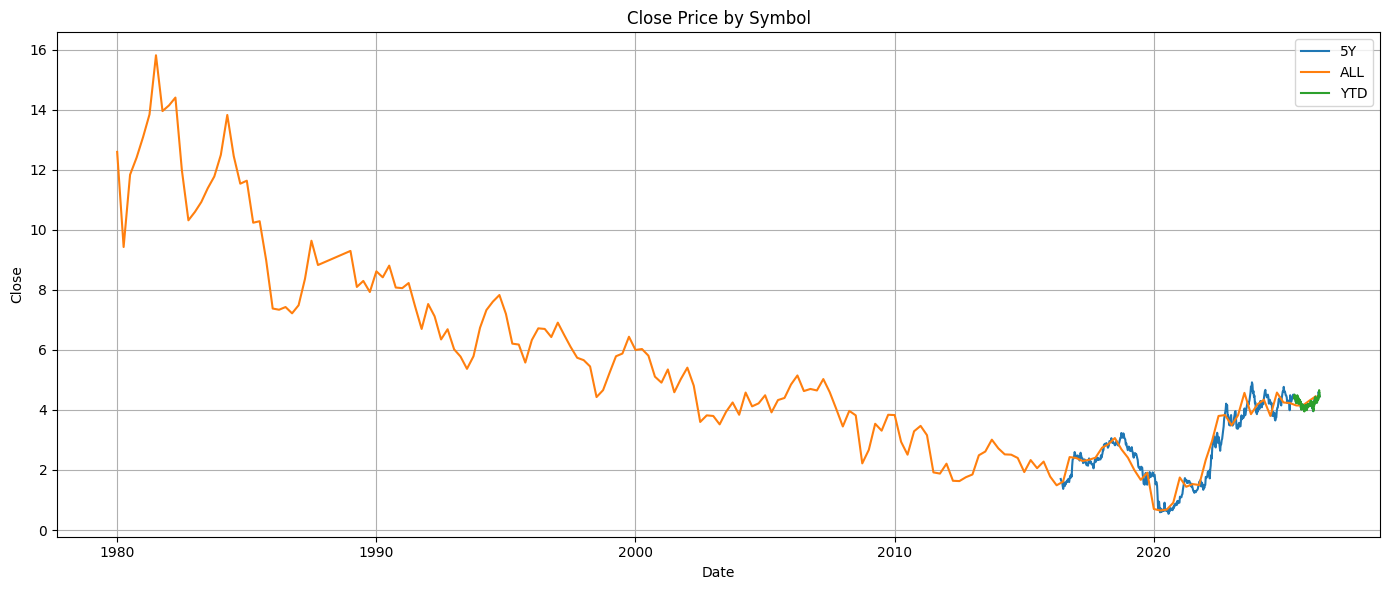

In [69]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

for symbol, df in pricebars_df.groupby("timeRange"):
    plt.plot(
        df["tradeTime"],
        df["close"],
        label=symbol
    )

plt.title("Close Price by Symbol")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

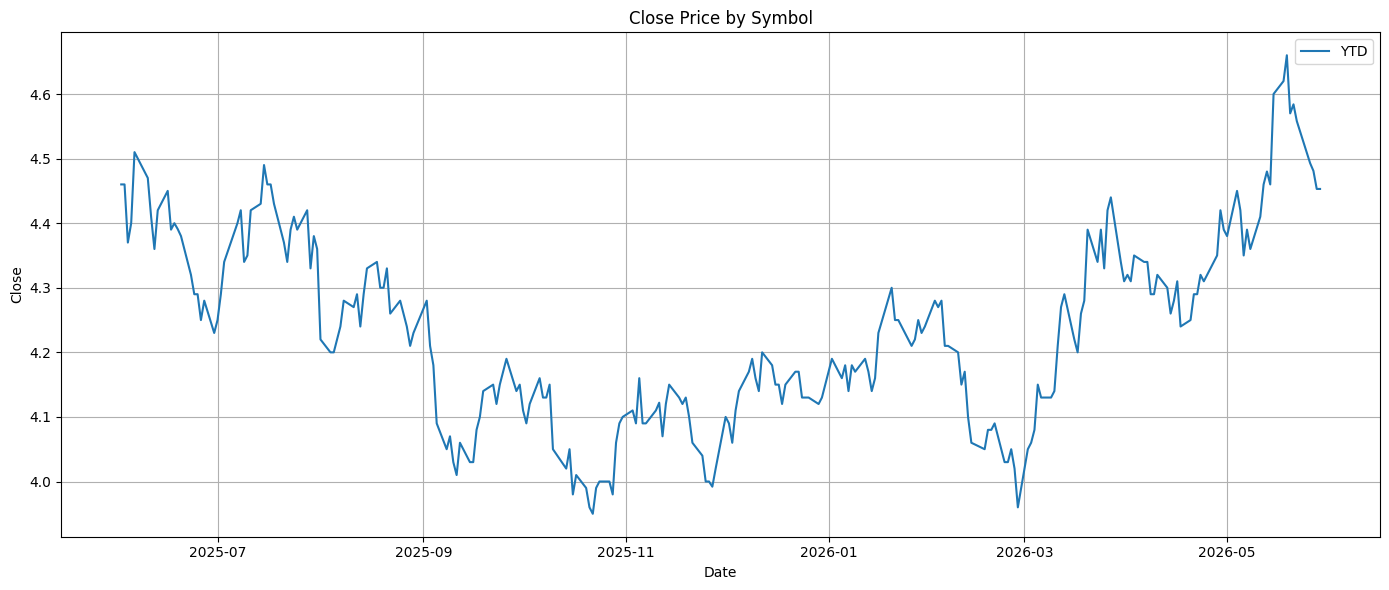

In [71]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df = symbol_dfs["YTD"]

plt.plot(
    df["tradeTime"],
    df["close"],
    label=symbol
)

plt.title("Close Price by Symbol")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

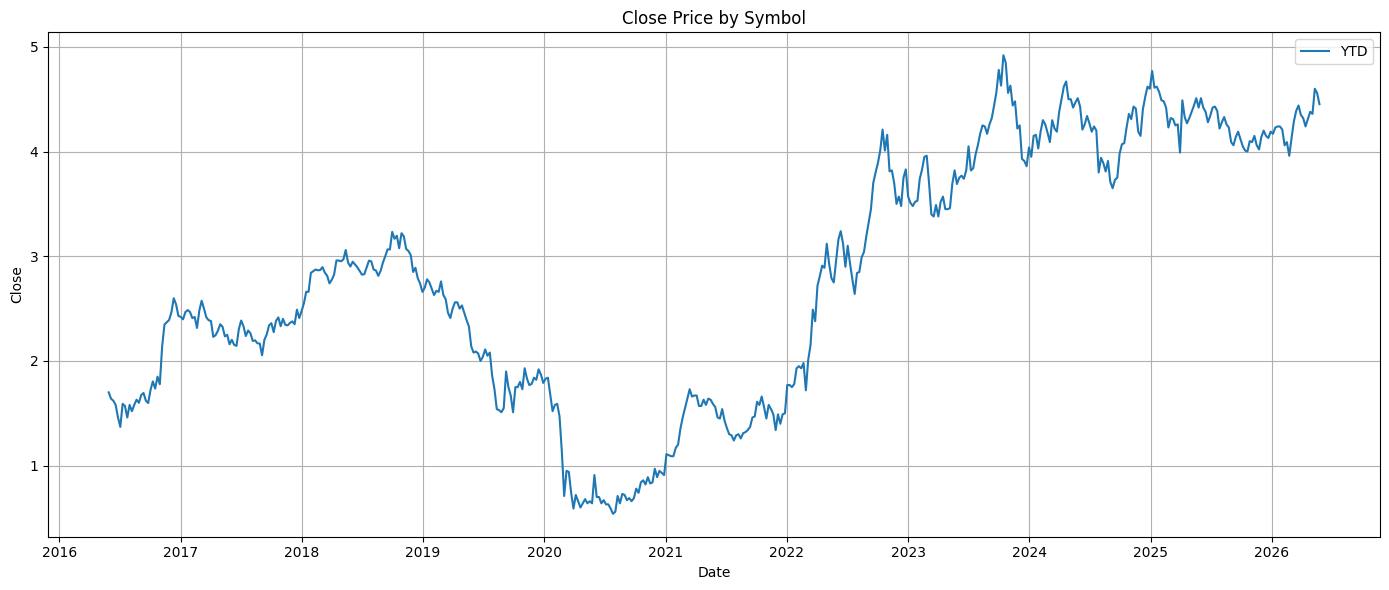

In [72]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

df = symbol_dfs["5Y"]

plt.plot(
    df["tradeTime"],
    df["close"],
    label=symbol
)

plt.title("Close Price by Symbol")
plt.xlabel("Date")
plt.ylabel("Close")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()